# XGBoost Weather Prediction — Training Notebook

Trains two XGBoost models consumed by the **Weather MCP server**:
- `weather_xgb_temp.json` — XGBRegressor predicting next observation temperature (°C)
- `weather_xgb_rain.json` — XGBClassifier predicting rain probability (binary)

**Data source:** [Open-Meteo Historical API](https://open-meteo.com/en/docs/historical-weather-api)
— free, no API key required, hourly data back to 1940.

**Features (10 total):**

| Feature | Description |
|---|---|
| `hour` | Hour of day (0–23, UTC) |
| `month` | Month (1–12) |
| `day_of_year` | Day of year (1–366) |
| `temp_lag1` | Temperature from the previous reading (°C) |
| `temp_lag2` | Temperature 2 readings ago (°C) |
| `temp_lag3` | Temperature 3 readings ago (°C) |
| `humidity` | Relative humidity (%) |
| `wind_speed` | Wind speed (m/s) |
| `pressure` | Atmospheric pressure (hPa) |
| `rain_lag1` | Precipitation from last reading (mm) |

**Trained on:** 5 geographically diverse cities × 2 years of hourly data (~87 k rows/city).

**After training:** place the saved `models/` directory next to `weather.py` and restart the MCP server.

## Step 1 — Imports

In [1]:
# Install (run once):
#   uv add pandas matplotlib scikit-learn xgboost requests
#   OR: pip install pandas matplotlib scikit-learn xgboost requests

import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
import xgboost as xgb
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    classification_report,
    roc_auc_score,
)

print(f'XGBoost  : {xgb.__version__}')
print(f'Pandas   : {pd.__version__}')
print(f'NumPy    : {np.__version__}')

XGBoost  : 3.2.0
Pandas   : 3.0.1
NumPy    : 2.4.3


## Step 2 — Fetch Historical Data from Open-Meteo

Open-Meteo provides ERA5-based reanalysis data at 1-hour resolution.
We fetch 5 cities spanning tropical, temperate, and continental climates so the
model generalises across diverse conditions.

> **No API key required.** Rate limit: 10 000 calls/day on the free tier.

In [2]:
CITIES = [
    {'name': 'London',   'lat':  51.5074, 'lon':  -0.1278},
    {'name': 'Mumbai',   'lat':  19.0760, 'lon':  72.8777},
    {'name': 'New_York', 'lat':  40.7128, 'lon': -74.0060},
    {'name': 'Tokyo',    'lat':  35.6762, 'lon': 139.6503},
    {'name': 'Sydney',   'lat': -33.8688, 'lon': 151.2093},
]
START_DATE = '2023-01-01'
END_DATE   = '2024-12-31'


def fetch_city(city: dict) -> pd.DataFrame:
    """Fetch hourly historical weather for one city from Open-Meteo."""
    url = 'https://archive-api.open-meteo.com/v1/archive'
    params = {
        'latitude':        city['lat'],
        'longitude':       city['lon'],
        'start_date':      START_DATE,
        'end_date':        END_DATE,
        'hourly':          'temperature_2m,relative_humidity_2m,wind_speed_10m,surface_pressure,precipitation',
        'wind_speed_unit': 'ms',   # m/s — same unit as OpenWeatherMap
        'timezone':        'UTC',
    }
    r = requests.get(url, params=params, timeout=120)
    r.raise_for_status()
    h = r.json()['hourly']
    return pd.DataFrame({
        'time':       pd.to_datetime(h['time']),
        'temp':       h['temperature_2m'],
        'humidity':   h['relative_humidity_2m'],
        'wind_speed': h['wind_speed_10m'],
        'pressure':   h['surface_pressure'],
        'rain':       h['precipitation'],
        'city':       city['name'],
    })


# Fetch all cities (takes ~20–40 s depending on connection)
dfs = []
for city in CITIES:
    print(f"Fetching {city['name']} ...", end=' ', flush=True)
    df = fetch_city(city)
    dfs.append(df)
    print(f'{len(df):,} rows')
    time.sleep(0.3)   # polite rate limiting

raw = pd.concat(dfs, ignore_index=True)
print(f'Total: {len(raw):,} rows across {raw["city"].nunique()} cities')
raw.head()

Fetching London ... 17,544 rows
Fetching Mumbai ... 17,544 rows
Fetching New_York ... 17,544 rows
Fetching Tokyo ... 17,544 rows
Fetching Sydney ... 17,544 rows
Total: 87,720 rows across 5 cities


,time,temp,humidity,wind_speed,pressure,rain,city
0,2023-01-01 00:00:00,11.2,94,6.37,1000.9,0.1,London
1,2023-01-01 01:00:00,11.9,85,8.63,1001.7,0.4,London
2,2023-01-01 02:00:00,11.0,80,8.71,1002.7,0.0,London
3,2023-01-01 03:00:00,10.4,78,8.53,1003.7,0.0,London
4,2023-01-01 04:00:00,10.2,77,7.71,1004.3,0.0,London


## Step 3 — Feature Engineering

We create:
- **Time features** — `hour`, `month`, `day_of_year` capture diurnal and seasonal cycles
- **Lag features** — last 3 temperature readings give the model short-term momentum
- **Rain lag** — previous precipitation is the strongest predictor of near-term rain
- **Targets** — `temp_next` (regression) and `rain_next` (binary classification, rain > 0.1 mm)

Lag operations are grouped by city to prevent data bleeding between cities.

In [3]:
FEATURE_NAMES = [
    'hour', 'month', 'day_of_year',
    'temp_lag1', 'temp_lag2', 'temp_lag3',
    'humidity', 'wind_speed', 'pressure', 'rain_lag1',
]


def build_features(df: pd.DataFrame) -> pd.DataFrame:
    """Add lag/time features and prediction targets, sorted by city then time."""
    df = df.copy().sort_values(['city', 'time']).reset_index(drop=True)

    # Time features
    df['hour']        = df['time'].dt.hour
    df['month']       = df['time'].dt.month
    df['day_of_year'] = df['time'].dt.day_of_year

    # Lag features (grouped per city to avoid inter-city bleed)
    for lag in [1, 2, 3]:
        df[f'temp_lag{lag}'] = df.groupby('city')['temp'].shift(lag)
    df['rain_lag1'] = df.groupby('city')['rain'].shift(1)

    # Prediction targets
    df['temp_next'] = df.groupby('city')['temp'].shift(-1)           # next °C
    df['rain_next'] = (df.groupby('city')['rain'].shift(-1) > 0.1).astype(int)  # 1 = rain

    return df.dropna(subset=FEATURE_NAMES + ['temp_next', 'rain_next'])


featured = build_features(raw)
print(f'Rows after feature engineering: {len(featured):,}')
print(f'Rain rate (next step):          {featured["rain_next"].mean():.1%}')
featured[FEATURE_NAMES + ['temp_next', 'rain_next']].describe().round(2)

Rows after feature engineering: 87,700
Rain rate (next step):          13.0%


,hour,month,day_of_year,temp_lag1,temp_lag2,temp_lag3,humidity,wind_speed,pressure,rain_lag1,temp_next,rain_next
count,87700.00,87700.00,87700.00,87700.00,87700.00,87700.00,87700.00,87700.00,87700.00,87700.00,87700.00,87700.00
mean,11.50,6.52,183.27,17.24,17.24,17.24,73.31,3.75,1010.08,0.16,17.24,0.13
std,6.92,3.45,105.49,8.88,8.88,8.88,17.70,2.10,8.15,0.73,8.88,0.34
min,0.00,1.00,1.00,-16.50,-16.50,-16.50,9.00,0.00,952.00,0.00,-16.50,0.00
25%,6.00,4.00,92.00,10.40,10.40,10.40,61.00,2.19,1005.20,0.00,10.40,0.00
50%,12.00,7.00,183.00,17.60,17.60,17.60,77.00,3.35,1009.80,0.00,17.60,0.00
75%,17.25,10.00,275.00,24.80,24.80,24.80,88.00,4.92,1014.70,0.00,24.80,0.00
max,23.00,12.00,366.00,41.30,41.30,41.30,100.00,21.12,1045.00,26.90,41.30,1.00


## Step 4 — Exploratory Data Analysis

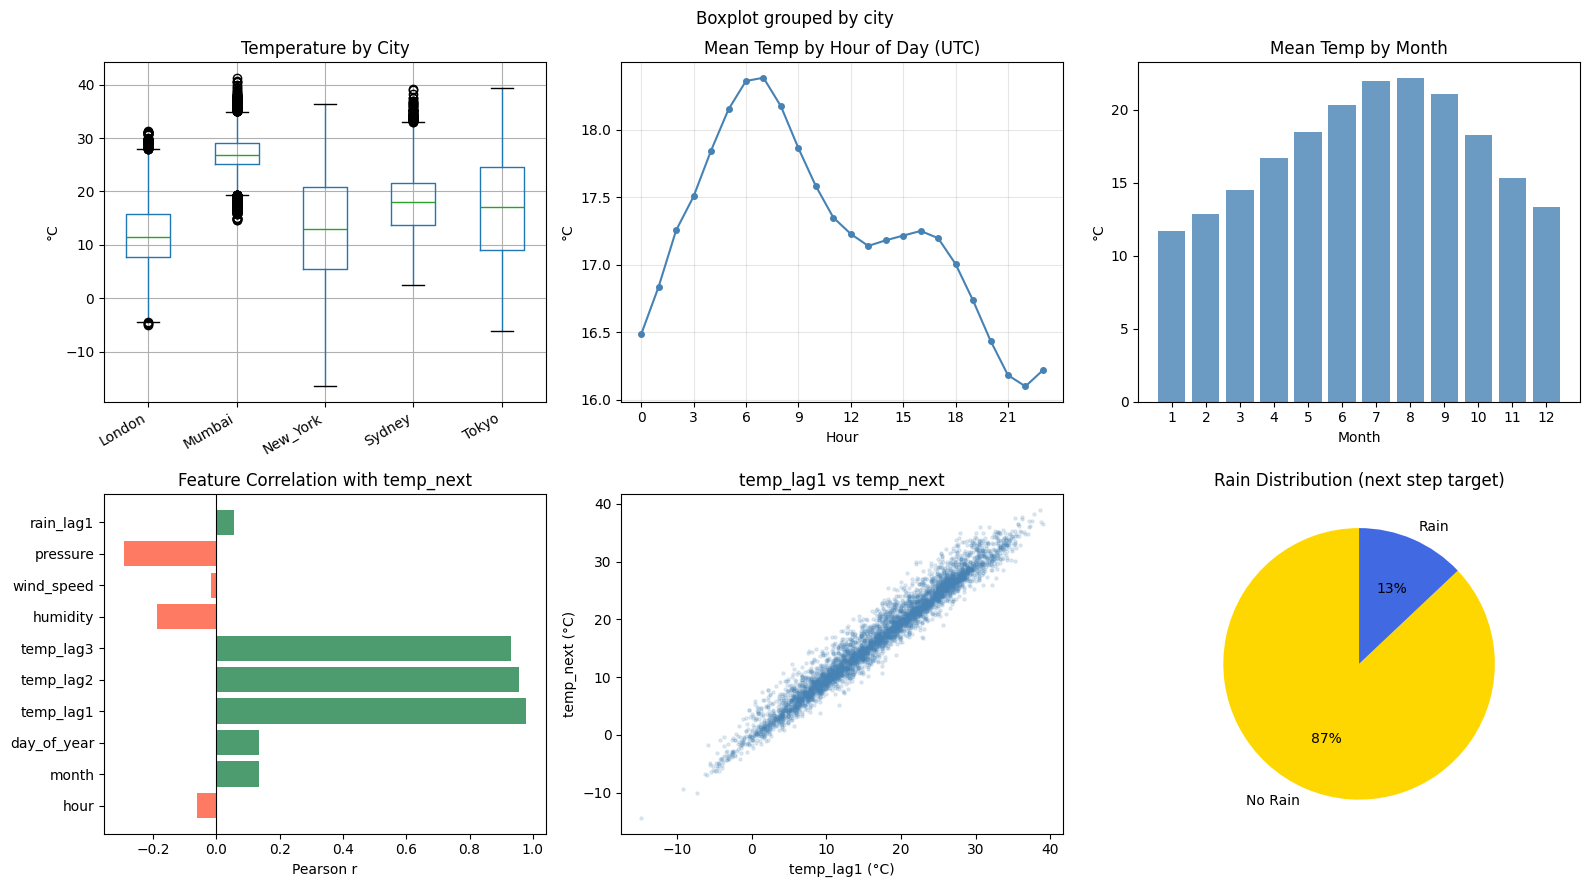

Saved: eda_overview.png


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Dataset Overview — 5 cities, 2 years of hourly data', fontsize=13, fontweight='bold')

# 1 — Temperature distribution per city
featured.boxplot(column='temp', by='city', ax=axes[0, 0])
axes[0, 0].set_title('Temperature by City')
axes[0, 0].set_xlabel('')
axes[0, 0].set_ylabel('°C')
plt.sca(axes[0, 0])
plt.xticks(rotation=30, ha='right')

# 2 — Hourly average (diurnal cycle)
hourly = featured.groupby('hour')['temp_lag1'].mean()
axes[0, 1].plot(hourly.index, hourly.values, marker='o', ms=4, color='steelblue')
axes[0, 1].set_title('Mean Temp by Hour of Day (UTC)')
axes[0, 1].set_xlabel('Hour')
axes[0, 1].set_ylabel('°C')
axes[0, 1].set_xticks(range(0, 24, 3))
axes[0, 1].grid(alpha=0.3)

# 3 — Monthly average (seasonal cycle)
monthly = featured.groupby('month')['temp_lag1'].mean()
axes[0, 2].bar(monthly.index, monthly.values, color='steelblue', alpha=0.8)
axes[0, 2].set_title('Mean Temp by Month')
axes[0, 2].set_xlabel('Month')
axes[0, 2].set_ylabel('°C')
axes[0, 2].set_xticks(range(1, 13))

# 4 — Feature correlations with temp_next
corrs = [featured[f].corr(featured['temp_next']) for f in FEATURE_NAMES]
colors = ['seagreen' if c > 0 else 'tomato' for c in corrs]
axes[1, 0].barh(FEATURE_NAMES, corrs, color=colors, alpha=0.85)
axes[1, 0].set_title('Feature Correlation with temp_next')
axes[1, 0].axvline(0, color='black', lw=0.8)
axes[1, 0].set_xlabel('Pearson r')

# 5 — Lag1 vs next temp scatter
sample = featured.sample(min(5000, len(featured)), random_state=42)
axes[1, 1].scatter(sample['temp_lag1'], sample['temp_next'],
                   alpha=0.15, s=5, color='steelblue')
axes[1, 1].set_title('temp_lag1 vs temp_next')
axes[1, 1].set_xlabel('temp_lag1 (°C)')
axes[1, 1].set_ylabel('temp_next (°C)')

# 6 — Rain class balance
rain_counts = featured['rain_next'].value_counts().sort_index()
axes[1, 2].pie(rain_counts.values, labels=['No Rain', 'Rain'],
               autopct='%1.0f%%', colors=['#FFD700', '#4169E1'], startangle=90)
axes[1, 2].set_title('Rain Distribution (next step target)')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved: eda_overview.png')

## Step 5 — Train/Test Split

We use a **chronological** 80/20 split — never shuffle time-series data.
Shuffled splits leak future information and produce optimistically biased metrics.

In [5]:
X      = featured[FEATURE_NAMES].values
y_temp = featured['temp_next'].values
y_rain = featured['rain_next'].values

split_idx = int(len(X) * 0.8)
X_train,      X_test      = X[:split_idx],      X[split_idx:]
y_temp_train, y_temp_test = y_temp[:split_idx], y_temp[split_idx:]
y_rain_train, y_rain_test = y_rain[:split_idx], y_rain[split_idx:]

print(f'Train : {len(X_train):>7,} rows  ({len(X_train)/len(X):.0%})')
print(f'Test  : {len(X_test):>7,} rows  ({len(X_test)/len(X):.0%})')

Train :  70,160 rows  (80%)
Test  :  17,540 rows  (20%)


## Step 6 — Train Temperature Regressor (XGBRegressor)

In [6]:
temp_model = xgb.XGBRegressor(
    n_estimators      = 400,
    learning_rate     = 0.05,
    max_depth         = 6,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    min_child_weight  = 5,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    random_state      = 42,
    n_jobs            = -1,
    verbosity         = 0,
)

temp_model.fit(
    X_train, y_temp_train,
    eval_set=[(X_test, y_temp_test)],
    verbose=False,
)

y_pred_temp = temp_model.predict(X_test)
mae  = mean_absolute_error(y_temp_test, y_pred_temp)
rmse = float(np.sqrt(mean_squared_error(y_temp_test, y_pred_temp)))

print('Temperature Regressor')
print(f'  MAE  : {mae:.2f} °C')
print(f'  RMSE : {rmse:.2f} °C')

Temperature Regressor
  MAE  : 1.15 °C
  RMSE : 1.61 °C


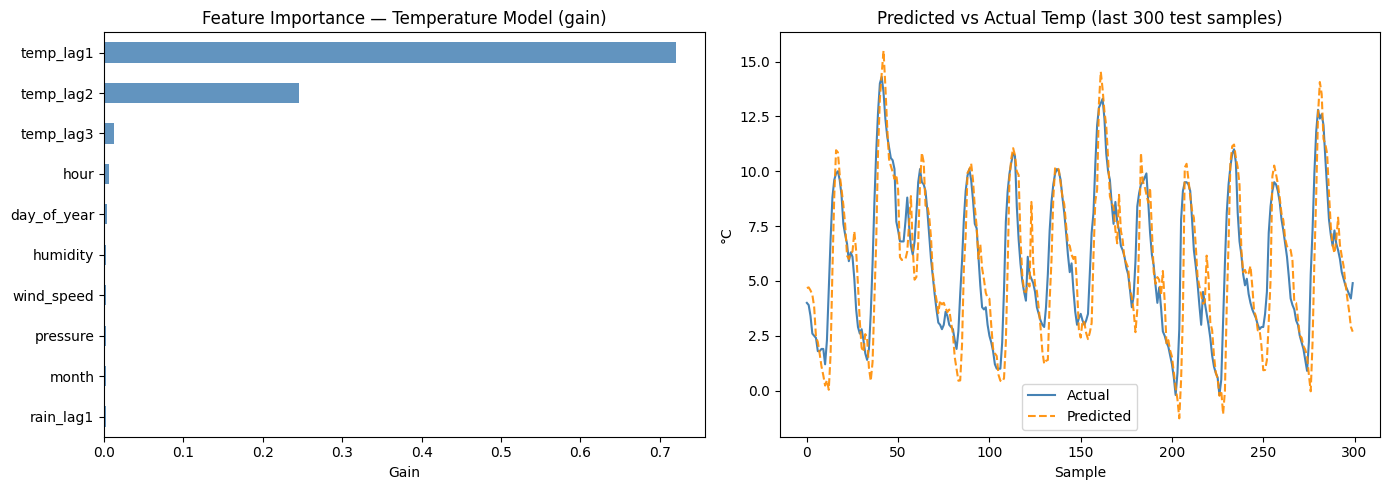

Saved: temp_model_eval.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Feature importance
imp = pd.Series(temp_model.feature_importances_, index=FEATURE_NAMES).sort_values()
imp.plot.barh(ax=axes[0], color='steelblue', alpha=0.85)
axes[0].set_title('Feature Importance — Temperature Model (gain)')
axes[0].set_xlabel('Gain')

# Predicted vs actual
n_plot = 300
axes[1].plot(y_temp_test[-n_plot:], label='Actual',    lw=1.5, color='steelblue')
axes[1].plot(y_pred_temp[-n_plot:], label='Predicted', lw=1.5, color='darkorange',
             linestyle='--', alpha=0.9)
axes[1].set_title(f'Predicted vs Actual Temp (last {n_plot} test samples)')
axes[1].set_xlabel('Sample')
axes[1].set_ylabel('°C')
axes[1].legend()

plt.tight_layout()
plt.savefig('temp_model_eval.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved: temp_model_eval.png')

## Step 7 — Train Rain Classifier (XGBClassifier)

Rain events are rare (typically 20–30 % of hours), creating class imbalance.
We use `scale_pos_weight` to correct for this — it's the ratio of negative to positive samples.

In [8]:
no_rain_n  = int((y_rain_train == 0).sum())
rain_n     = int((y_rain_train == 1).sum())
imbalance  = no_rain_n / rain_n
print(f'No-rain : {no_rain_n:,}   Rain : {rain_n:,}   Ratio : {imbalance:.1f}:1')

rain_model = xgb.XGBClassifier(
    n_estimators      = 300,
    learning_rate     = 0.05,
    max_depth         = 5,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    min_child_weight  = 5,
    scale_pos_weight  = imbalance,   # handles class imbalance
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    eval_metric       = 'logloss',
    random_state      = 42,
    n_jobs            = -1,
    verbosity         = 0,
)

rain_model.fit(
    X_train, y_rain_train,
    eval_set=[(X_test, y_rain_test)],
    verbose=False,
)

y_pred_rain = rain_model.predict(X_test)
y_prob_rain = rain_model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_rain_test, y_prob_rain)

print(f'Rain Classifier — AUC-ROC : {auc:.3f}')
print()
print(classification_report(y_rain_test, y_pred_rain, target_names=['No Rain', 'Rain']))

No-rain : 60,924   Rain : 9,236   Ratio : 6.6:1
Rain Classifier — AUC-ROC : 0.884

              precision    recall  f1-score   support

     No Rain       0.97      0.81      0.88     15412
        Rain       0.36      0.79      0.50      2128

    accuracy                           0.81     17540
   macro avg       0.66      0.80      0.69     17540
weighted avg       0.89      0.81      0.83     17540



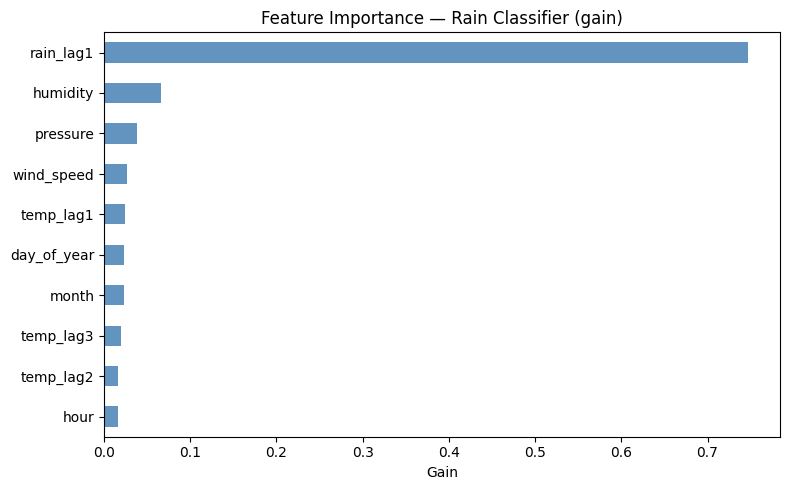

Saved: rain_model_importance.png


In [9]:
# Feature importance for rain model
fig, ax = plt.subplots(figsize=(8, 5))
imp_rain = pd.Series(rain_model.feature_importances_, index=FEATURE_NAMES).sort_values()
imp_rain.plot.barh(ax=ax, color='steelblue', alpha=0.85)
ax.set_title('Feature Importance — Rain Classifier (gain)')
ax.set_xlabel('Gain')
plt.tight_layout()
plt.savefig('rain_model_importance.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved: rain_model_importance.png')

## Step 8 — Save Models

Models are saved in XGBoost's native JSON format — portable, human-readable, and version-independent.
The `feature_names.json` file documents the exact feature order required at inference time.

In [10]:
MODEL_DIR = Path('models')
MODEL_DIR.mkdir(exist_ok=True)

temp_model.save_model(MODEL_DIR / 'weather_xgb_temp.json')
rain_model.save_model(MODEL_DIR / 'weather_xgb_rain.json')

with open(MODEL_DIR / 'feature_names.json', 'w') as fh:
    json.dump(FEATURE_NAMES, fh, indent=2)

print('Models saved:')
for p in sorted(MODEL_DIR.iterdir()):
    if p.name == '.gitkeep':
        continue
    size_kb = p.stat().st_size / 1024
    print(f'  {str(p):<42}  {size_kb:6.0f} KB')

print()
print('Next steps:')
print('  1. Ensure models/ directory is next to weather.py')
print('  2. Run:  uv sync        (adds xgboost to the venv)')
print('  3. Restart the MCP server — models auto-load on start')

Models saved:
  models/feature_names.json                        0 KB
  models/weather_xgb_rain.json                   995 KB
  models/weather_xgb_temp.json                  2427 KB

Next steps:
  1. Ensure models/ directory is next to weather.py
  2. Run:  uv sync        (adds xgboost to the venv)
  3. Restart the MCP server — models auto-load on start


## Step 9 — Smoke Test (verify reload)

Reload from disk and run one prediction — simulates what `weather.py` does at startup.

In [11]:
_temp_check = xgb.XGBRegressor()
_temp_check.load_model(MODEL_DIR / 'weather_xgb_temp.json')
_rain_check = xgb.XGBClassifier()
_rain_check.load_model(MODEL_DIR / 'weather_xgb_rain.json')

# Simulate: 2 PM UTC, mid-March, London-like conditions
test_X = np.array([[
    14,      # hour
    3,       # month
    82,      # day_of_year
    11.5,    # temp_lag1  (°C)
    11.2,    # temp_lag2
    10.9,    # temp_lag3
    72.0,    # humidity   (%)
    4.2,     # wind_speed (m/s)
    1013.2,  # pressure   (hPa)
    0.0,     # rain_lag1  (mm)
]])

pred_temp = float(_temp_check.predict(test_X)[0])
pred_rain = float(_rain_check.predict_proba(test_X)[0][1])

rain_label = 'Yes' if pred_rain > 0.4 else ('Possible' if pred_rain > 0.2 else 'Unlikely')

print('Smoke test (London, 14:00 UTC, 11.5 deg C, 72% humidity)')
print(f'  Predicted next temp  : {pred_temp:.1f} deg C')
print(f'  Rain probability     : {pred_rain*100:.0f}%  -> {rain_label}')
print()
print('Model reload successful — MCP server is ready.')

Smoke test (London, 14:00 UTC, 11.5 deg C, 72% humidity)
  Predicted next temp  : 11.6 deg C
  Rain probability     : 29%  -> Possible

Model reload successful — MCP server is ready.
